In [1]:
import adios4dolfinx
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

from dolfinx.fem.petsc import LinearProblem
from ufl import sqrt, inner, TestFunction, TrialFunction, dot, grad, CellDiameter, dx
from pathlib import Path
from mpi4py import MPI
from dolfinx import mesh, fem, io, plot
from basix.ufl import element


In [2]:
wind_file = Path("../wind_data/airflow_ipcs.bp")
#wind_file = Path("../wind_data/airflow_picard.bp")
domain = adios4dolfinx.read_mesh(wind_file, MPI.COMM_WORLD)

dom_cell = domain.basix_cell()
V2 = fem.functionspace(domain, element("Lagrange", dom_cell, 2, shape=(domain.topology.dim,)))
V_wind = fem.functionspace(domain, element("Lagrange", dom_cell, 2, shape=(domain.topology.dim,)))

beta_V2 = fem.Function(V2)
adios4dolfinx.read_function(wind_file, beta_V2, name="velocity_H2")

beta = fem.Function(V_wind)
beta.interpolate(beta_V2)

topology, cell_type, geom = plot.vtk_mesh(V_wind) 
grid = pv.UnstructuredGrid(topology, cell_type, geom)

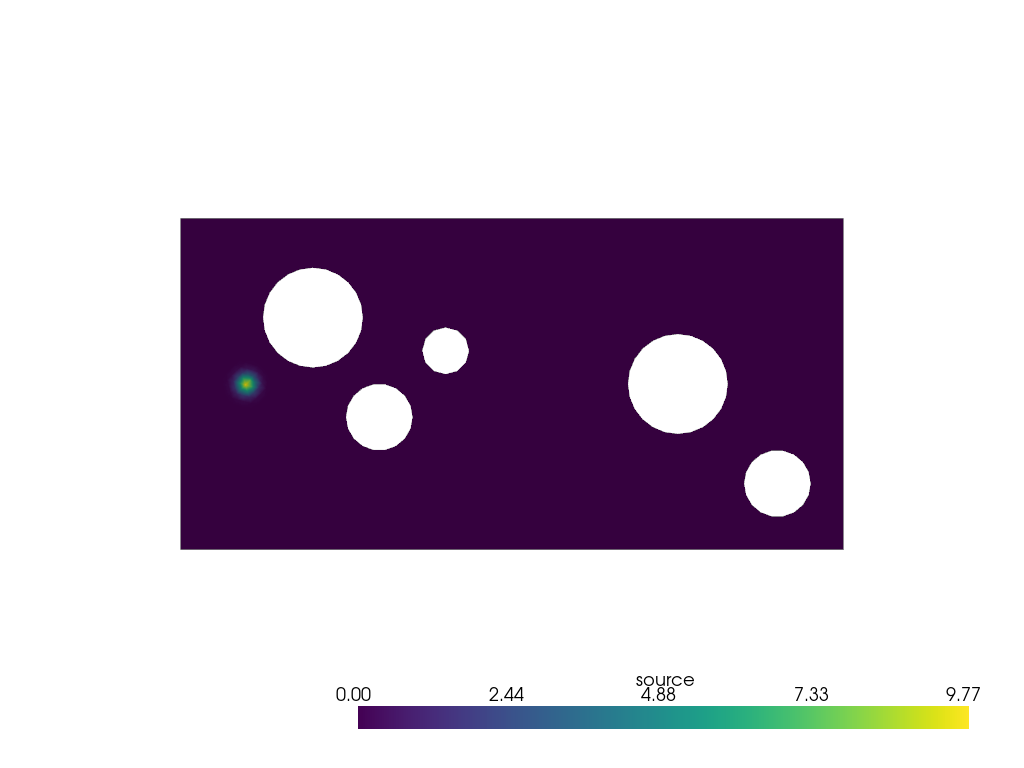

In [3]:
coords = domain.geometry.x
x_min, y_min = np.min(coords[:, 0]), np.min(coords[:, 1])
x_max, y_max = np.max(coords[:, 0]), np.max(coords[:, 1])

x_lim = x_max - x_min
y_lim = y_max - y_min

x0, y0 = 0.1 * x_lim, 0.5 * y_lim
sigma_x, sigma_y = 0.01 * x_lim, 0.01 * x_lim

# Source term as 2D-Gauss
def source_term(x: np.ndarray):
    return 10.0 * np.exp(-((x[0] - x0)**2 / (2 * sigma_x**2) + (x[1] - y0)**2 / (2 * sigma_y**2)))

V_scalar = fem.functionspace(domain, element("CG", domain.basix_cell(), 2))
f_true = fem.Function(V_scalar)
f_true.interpolate(source_term)

# Boundary condition (zero dirichlet)
def boundary(x):
    return np.isclose(x[0], x_min)

u_zero = fem.Constant(domain, 0.0)
bc_zero = fem.dirichletbc(u_zero, fem.locate_dofs_geometrical(V_scalar, boundary), V_scalar)

#Plot
grid.point_data["source"] = f_true.x.array
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars="source", cmap="viridis", show_edges=False)
plotter.view_xy()
plotter.show()

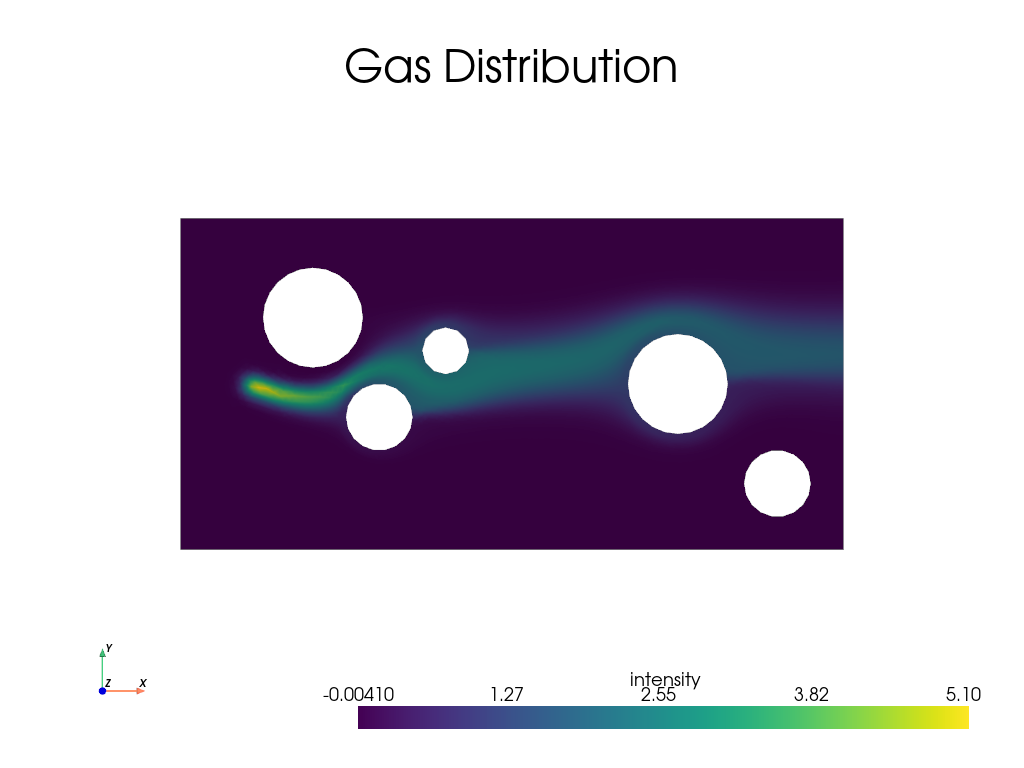

In [4]:
# Forward simulation
D_phys = D_phys = fem.Constant(domain, 0.01)
U_char = sqrt(dot(beta, beta))
L_char = fem.Constant(domain, x_lim)
h = CellDiameter(domain)
Pe = U_char * L_char / D_phys
nb = sqrt(inner(beta, beta))

tau = 0.5 * h * pow(4.0 / (Pe*h) + 2.0 * nb, -1.0)

v = TestFunction(V_scalar)
u = TrialFunction(V_scalar)
f = fem.Function(V_scalar)

# For true solution: set f to the value of the true source
f = f_true

# SUPG version for linear and bilinear form
a = D_phys * inner(grad(u), grad(v)) * dx + inner(beta, grad(u)) * v * dx + \
         tau * inner(beta, grad(u)) * inner(beta, grad(v)) * dx
L = f * v * dx + tau * f * inner(beta, grad(v)) * dx

forward_problem = LinearProblem(a, L, [bc_zero])

c_true = forward_problem.solve()

# Plot
grid.point_data["intensity"] = c_true.x.array 
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars="intensity", cmap="viridis", show_edges=False)
plotter.add_title("Gas Distribution")
plotter.view_xy()
plotter.show_axes()
#plotter.show_grid()

plotter.show()


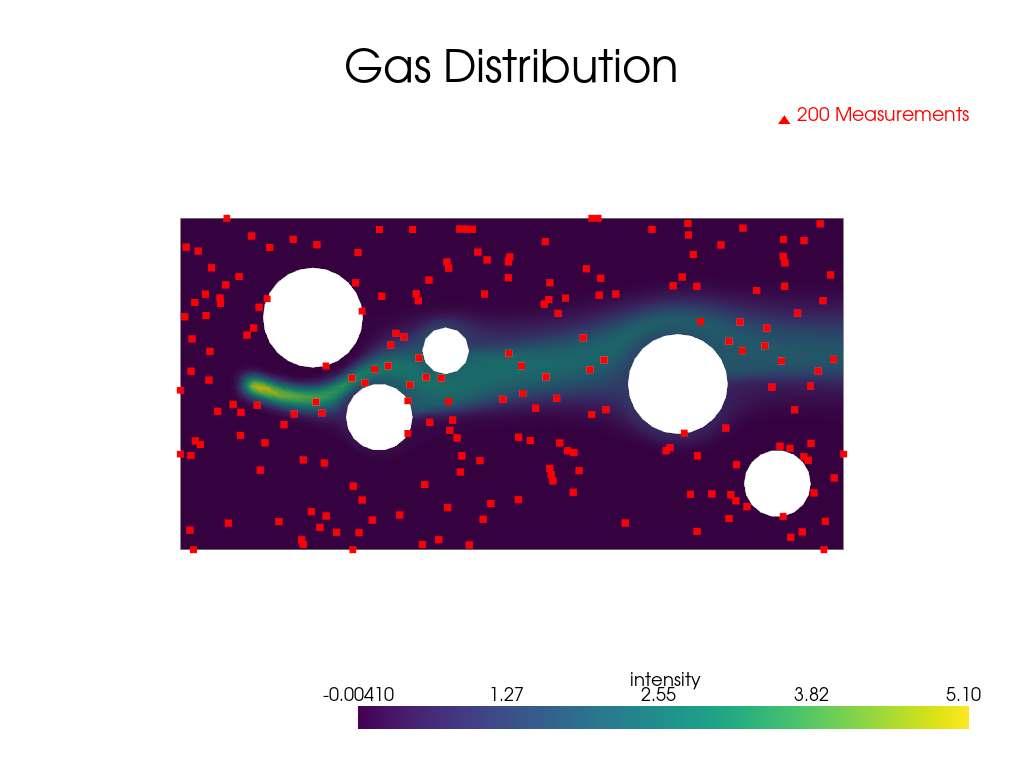

In [5]:
# Select values from c in m
n = len(c_true.x.array)
n_measurements = 200 # int(0.01 * n)

# # random distribution
np.random.seed(1) # Good vals: 9
m_ids = np.random.choice(np.arange(n), size=n_measurements, replace=False) # random distribution

m = c_true.x.array[m_ids]

# Plot
grid.point_data["intensity"] = c_true.x.array 
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars="intensity", cmap="viridis", show_edges=False)
selected_points = grid.points[m_ids]

plotter.add_points(
    selected_points,
    color="red",        
    point_size=7,
    label=f"{n_measurements} Measurements")
plotter.add_title("Gas Distribution")
plotter.view_xy()
#plotter.show_grid()
plotter.add_legend()
plotter.show()



In [6]:
# Inverse Problem

lagrange_mult = TrialFunction(V_scalar)
residual = fem.Function(V_scalar)
residual.x.array[:] = 0.0

a_adj = D_phys * inner(grad(v), grad(lagrange_mult)) * dx \
        + inner(beta, grad(v)) * lagrange_mult * dx \
        + tau * inner(beta, grad(v)) * inner(beta, grad(lagrange_mult)) * dx
L_adj = inner(residual, v) * dx \
        + tau * inner(beta, grad(v)) * residual * dx

adjoint_problem = LinearProblem(a_adj, L_adj, [bc_zero])

In [ ]:
# Iteration loop old

m = c_true.x.array[m_ids]
f.x.array[:] = 0.0

max_it = 20
shrink_threshold = 3e-1
gamma_reg = 1e-1
alpha0 = 1.0
tol_rel = 1e-3
tol_grad = 1e-4
c_arm = 1e-3
rho = 0.5
alpha_hist = []
misfit_hist = []

def compute_misfit(c_func: fem.Function, f_func: fem.Function):
    res = c_func.x.array[m_ids] - m
    # return 0.5 * np.dot(res, res) + 0.5 * gamma * np.dot(f_func.x.array, f_func.x.array) # L2
    return np.dot(res, res) + 0.5 * gamma_reg * np.sum(np.abs(f_func.x.array)) # L1

for it in range(max_it):
    # forward
    c = forward_problem.solve()

    # Current misfit
    mis = compute_misfit(c, f)

    # Set adjoint rhs setzen und lösen
    residual.x.array[:] = 0.0
    residual.x.array[m_ids] = -(c.x.array[m_ids] - m)
    adj = adjoint_problem.solve()

    # Gradient
    # gradJ = -adj.x.array + gamma * f.x.array # L2
    gradJ = -adj.x.array # L1 smooth gradient (without regularization term)
    grad_norm = np.linalg.norm(gradJ) 

    alpha = alpha0
    f_old = f.x.array.copy()

    # Armijo search
    while True:
        # L1
        y = f_old - alpha * gradJ
        f.x.array[:] = np.sign(y) * np.maximum(np.abs(y) - alpha * gamma_reg, 0.0)
        # L2
        # f.x.array[:] = f_old - alpha * gradJ
        
        c_trial = forward_problem.solve()
        mis_trial = compute_misfit(c_trial, f)

        if mis_trial <= mis - c_arm * alpha * grad_norm**2:
            break
        alpha *= rho
    if alpha < 1e-14:
        if grad_norm > tol_grad:
            print("Alpha too small.")
    
    mis_new = compute_misfit(c_trial, f)
    misfit_hist.append(mis_new)
    alpha_hist.append(alpha)

    if it % 10 == 0 or it == max_it-1:
        print(f"it {it:3d} mis={mis:.3e} ||grad||={grad_norm:.3e}")

    # Convergence
    if it > 1:
        rel_change = abs(misfit_hist[-2] - misfit_hist[-1]) / max(1e-12, misfit_hist[-2])
        if rel_change < tol_rel or grad_norm < tol_grad:
            print(f"Stopped at it {it}, rel. change={rel_change:.3e}")
            break
# alpha_hist

# Visualize result
grid.point_data["source"] = f.x.array
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars="source", cmap="viridis", show_edges=False)

# -------------------------------------------------------
# True source position (Red)
# -------------------------------------------------------
true_source_location = np.array([x0, y0, 0])
true_marker = pv.PolyData([true_source_location])
plotter.add_mesh(
    true_marker,
    color="red",
    point_size=12,
    label="True Source Location"
)

# -------------------------------------------------------
# Estimated source (Maximum of f) – Orange
# -------------------------------------------------------

# 1. DOF coordinates (matching f.x.array ordering!)
coords = V_scalar.tabulate_dof_coordinates()  # shape (ndofs, gdim)

# 2. Index of max(f)
idx_max = np.argmax(f.x.array)

# 3. DOF coordinate of source location
max_point = coords[idx_max]

# 4. Add orange point to plot
est_marker = pv.PolyData([max_point])
plotter.add_mesh(
    est_marker,
    color="orange",
    point_size=12,
    label="Estimated Source (max f)"
)

# -------------------------------------------------------
# Show plot
# -------------------------------------------------------
plotter.view_xy()
plotter.add_legend()
plotter.show()

print("Estimated source maximum at:", max_point)

it   0 mis=1.303e+02 ||grad||=3.161e+01
it  10 mis=6.813e+00 ||grad||=3.775e+00
Alpha too small.
Stopped at it 12, rel. change=8.463e-16


IndexError: index 4877 is out of bounds for axis 0 with size 1600

In [ ]:
# m = c_true.x.array[m_ids]
# f.x.array[:] = 0.0

# max_it = 15
# gamma = 1e-3          # erstmal deutlich kleiner probieren
# alpha0 = 1.0          # kleiner als 10
# tol_rel = 1e-7
# tol_grad = 1e-8
# c_arm = 1e-3
# rho = 0.5

# alpha_hist = []
# misfit_hist = []

# def compute_misfit(c_func: fem.Function, f_func: fem.Function):
#     r = c_func.x.array[m_ids] - m
#     return 0.5 * np.dot(r, r) + 0.5 * gamma * np.dot(f_func.x.array, f_func.x.array)

# for it in range(max_it):
#     # forward
#     c = forward_problem.solve()
#     mis = compute_misfit(c, f)

#     # adjoint RHS: - (Mc - m)
#     residual.x.array[:] = 0.0
#     residual.x.array[m_ids] = -(c.x.array[m_ids] - m)
#     adj = adjoint_problem.solve()

#     # Gradient: gradJ = γ f - λ = -adj + γ f
#     gradJ = -adj.x.array + gamma * f.x.array
#     grad_norm = np.linalg.norm(gradJ)

#     alpha = alpha0
#     f_old = f.x.array.copy()

#     # Armijo
#     while True:
#         f.x.array[:] = f_old - alpha * gradJ

#         # optional: Physikalische Positivität erzwingen
#         f.x.array[f.x.array < 0.0] = 0.0

#         c_trial = forward_problem.solve()
#         mis_trial = compute_misfit(c_trial, f)

#         if mis_trial <= mis - c_arm * alpha * grad_norm**2:
#             break
#         alpha *= rho
#         if alpha < 1e-14:
#             print("Alpha too small.")
#             break

#     misfit_hist.append(mis_trial)
#     alpha_hist.append(alpha)

#     if it % 10 == 0 or it == max_it-1:
#         print(f"it {it:3d} mis={mis:.3e} ||grad||={grad_norm:.3e} α={alpha:.2e}")

#     if it > 1:
#         rel_change = abs(misfit_hist[-2] - misfit_hist[-1]) / max(1e-12, misfit_hist[-2])
#         if rel_change < tol_rel or grad_norm < tol_grad:
#             print(f"Stopped at it {it}, rel. change={rel_change:.3e}")
#             break


# # Visualize result
# grid.point_data["source"] = f.x.array 
# plotter = pv.Plotter()
# plotter.add_mesh(grid, scalars="source", cmap="viridis", show_edges=False)

# true_source_location = np.array([x0, y0, 0])
# marker_mesh = pv.PolyData(true_source_location)
# plotter.add_mesh(marker_mesh,
#                  color='red',  
#                  label="True Source Location",
#                  point_size=6,
#                  opacity=1)
# # plotter.add_legend()

# plotter.view_xy()
# plotter.show_axes()
# plotter.show()
# print(f"Max source estimate: {max(f.x.array)}")